In [1]:
import sys
print(sys.executable)

/Users/arman/Desktop/GitHub/Plant_Disease_Machine_Learning_Modeling/.venv/bin/python


In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


pd.set_option("display.max_columns", 200)
np.random.seed(0)

the first dataset is plant disease oberservations

The second dataset is enviromental climate data 

In [3]:
disease_url = "https://raw.githubusercontent.com/ArmanMoshasha/Plant_Disease_Machine_Learning_Modeling/main/Dyrad%20Dataset%20project1/data/raw/complete_plant_disease_database.csv"

climate_url = "https://raw.githubusercontent.com/ArmanMoshasha/Plant_Disease_Machine_Learning_Modeling/main/Dyrad%20Dataset%20project1/data/raw/complete_plant_study_climate_data.csv"

disease = pd.read_csv(disease_url)
climate = pd.read_csv(climate_url)

disease.shape, climate.shape

((5906, 44), (5906, 12))

dataset structure understanding

In [4]:
disease.head()

,NUM_ID,First_author,Study_Year,Person_extracting,Date_extracted,Paper_double_checked,Short reference,Host.species,Host_family,Host_order,Host_strain,Host_type,Host_age,Habitat,Water,Parasite_or_pest,Antagonist_species,Antagonist_isolate,Antagonist_type_specific,Antagonist_type_general,Detection_method,Transmission_mode,Vector_type,Vector_species,Latitude,Longitude,Coordinates_provided_in_study,Location,Natural_or_ag,Sample_type,Same_plants_tested_multiple,Time_point,Months,Year,Start Date (yyyymm),Span (months),Number_sampled_locations,Coarse_spatial_scale,Approx_spatial_accuracy_width_km,Response metric,n,Infected,Incidence,Obs
0,715,Abbate,2014,Vianda,2021-06-30,Devin,Abbate_2014,Silene vulgaris,Caryophyllaceae,Caryophyllales,NaN,Wildflower,NaN,Terrestrial,NaN,Parasite,Microbotryum spp.,NaN,Fungus,Eukaryotic parasite,Visual,vectorborne and sexually-transmitted,pollinators,NaN,45.367,6.029,Yes,Areas surrounding the Jardin Alpin du Lautaret...,Natural,Plant,No,0,August,2008,200808,1,1.0,Plot,1,Incidence,28,0.0,0.000000,1
1,715,Abbate,2014,Vianda,2021-06-30,Devin,Abbate_2014,Silene vulgaris,Caryophyllaceae,Caryophyllales,NaN,Wildflower,NaN,Terrestrial,NaN,Parasite,Microbotryum spp.,NaN,Fungus,Eukaryotic parasite,Visual,vectorborne and sexually-transmitted,pollinators,NaN,45.393,6.117,Yes,Areas surrounding the Jardin Alpin du Lautaret...,Natural,Plant,No,0,August,2008,200808,1,1.0,Plot,1,Incidence,10,0.0,0.000000,2
2,715,Abbate,2014,Vianda,2021-06-30,Devin,Abbate_2014,Silene vulgaris,Caryophyllaceae,Caryophyllales,NaN,Wildflower,NaN,Terrestrial,NaN,Parasite,Microbotryum spp.,NaN,Fungus,Eukaryotic parasite,Visual,vectorborne and sexually-transmitted,pollinators,NaN,45.392,6.122,Yes,Areas surrounding the Jardin Alpin du Lautaret...,Natural,Plant,No,0,August,2008,200808,1,1.0,Plot,1,Incidence,15,0.0,0.000000,3
3,715,Abbate,2014,Vianda,2021-06-30,Devin,Abbate_2014,Silene vulgaris,Caryophyllaceae,Caryophyllales,NaN,Wildflower,NaN,Terrestrial,NaN,Parasite,Microbotryum spp.,NaN,Fungus,Eukaryotic parasite,Visual,vectorborne and sexually-transmitted,pollinators,NaN,45.381,6.148,Yes,Areas surrounding the Jardin Alpin du Lautaret...,Natural,Plant,No,0,August,2008,200808,1,1.0,Plot,1,Incidence,72,2.0,0.027778,4
4,715,Abbate,2014,Vianda,2021-06-30,Devin,Abbate_2014,Silene vulgaris,Caryophyllaceae,Caryophyllales,NaN,Wildflower,NaN,Terrestrial,NaN,Parasite,Microbotryum spp.,NaN,Fungus,Eukaryotic parasite,Visual,vectorborne and sexually-transmitted,pollinators,NaN,45.403,6.083,Yes,Areas surrounding the Jardin Alpin du Lautaret...,Natural,Plant,No,0,August,2008,200808,1,1.0,Plot,1,Incidence,30,0.0,0.000000,5


In [5]:
climate.head()

,system:index,Location,obs,bio01,bio12,end_date,prec,start_date,tavg,temperature_2m,total_precipitation,.geo
0,0,Areas surrounding the Jardin Alpin du Lautaret...,1,95.853316,943.493736,2008-08-31T00:00:00,78.747861,2008-08-01T00:00:00,181.284576,288.956314,0.005280,"{""type"":""Polygon"",""coordinates"":[[[6.028999805..."
1,1,Areas surrounding the Jardin Alpin du Lautaret...,2,50.894780,1283.165287,2008-08-31T00:00:00,96.436140,2008-08-01T00:00:00,133.753340,288.499283,0.005288,"{""type"":""Polygon"",""coordinates"":[[[6.117000102..."
2,2,Areas surrounding the Jardin Alpin du Lautaret...,3,46.951686,1317.325816,2008-08-31T00:00:00,98.158494,2008-08-01T00:00:00,129.520853,288.499283,0.005288,"{""type"":""Polygon"",""coordinates"":[[[6.122000217..."
3,3,Areas surrounding the Jardin Alpin du Lautaret...,4,30.425471,1458.278376,2008-08-31T00:00:00,106.305506,2008-08-01T00:00:00,112.943493,288.128423,0.005225,"{""type"":""Polygon"",""coordinates"":[[[6.147999763..."
4,4,Areas surrounding the Jardin Alpin du Lautaret...,5,102.943483,898.312969,2008-08-31T00:00:00,77.168637,2008-08-01T00:00:00,189.015197,288.499283,0.005288,"{""type"":""Polygon"",""coordinates"":[[[6.083000183..."


In [6]:
disease.info()
climate.info()

<class 'pandas.DataFrame'>
RangeIndex: 5906 entries, 0 to 5905
Data columns (total 44 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   NUM_ID                            5906 non-null   str    
 1   First_author                      5906 non-null   str    
 2   Study_Year                        5906 non-null   int64  
 3   Person_extracting                 5906 non-null   str    
 4   Date_extracted                    5906 non-null   str    
 5   Paper_double_checked              5906 non-null   str    
 6   Short reference                   5906 non-null   str    
 7   Host.species                      5864 non-null   str    
 8   Host_family                       5882 non-null   str    
 9   Host_order                        5882 non-null   str    
 10  Host_strain                       725 non-null    str    
 11  Host_type                         5903 non-null   str    
 12  Host_age         

The data is merged together using the observation identifier

In [7]:
df = disease.merge(climate, left_on="Obs", right_on="obs", how="inner")
df.shape


(5906, 56)

duplicates removed

In [8]:
df.isna().sum().sort_values(ascending=False).head(20)

Water                       5851
Antagonist_isolate          5777
Host_age                    5368
Host_strain                 5181
Vector_species              2815
Vector_type                 2579
Transmission_mode           1442
prec                         525
tavg                         525
Number_sampled_locations     190
Coarse_spatial_scale          83
temperature_2m                43
total_precipitation           43
Host.species                  42
Antagonist_species            38
Host_order                    24
Host_family                   24
Host_type                      3
bio12                          3
bio01                          3
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates().copy()

incorrect variable types removed, invalid variable types are removed to preform acurate statistical analysis

In [11]:
num_cols = ["Year","Latitude","Longitude","Incidence","n","Infected","bio01","bio12"]

for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

cat_cols = ["Habitat","Natural_or_ag","Host.species","Parasite_or_pest"]

for c in cat_cols:
    if c in df.columns:
        df[c] = df[c].astype("category")

df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")
df["end_date"] = pd.to_datetime(df["end_date"], errors="coerce")

Removed rows lacking enviromental data or outcome in general

In [12]:
df_clean = df.dropna(subset=["Incidence","bio01","bio12"]).copy()
df_clean.shape

(5903, 56)

summary statistics

In [13]:
df_clean.groupby("Natural_or_ag")["Incidence"].mean()

Natural_or_ag
Ag                  0.164286
Botanical Garden    0.093220
Natural             0.159391
Name: Incidence, dtype: float64

In [13]:
df_clean[["Incidence","bio01","bio12"]].describe()

,Incidence,bio01,bio12
count,5903.000000,5903.000000,5903.000000
mean,0.163464,160.204584,792.099124
std,0.259912,63.979352,481.032453
min,0.000000,-3.949332,2.027794
25%,0.000000,119.632702,404.431911
50%,0.020000,155.342208,752.418102
75%,0.220000,209.385012,1105.482213
max,1.000000,310.888808,3899.700752


Histogram: the distribution of disease incidence is shown to be stronging right skewed, observations show very low inflection levels and few high incidence observations. this means that disease outbreaks in plants are generally uncommon events in populations. 

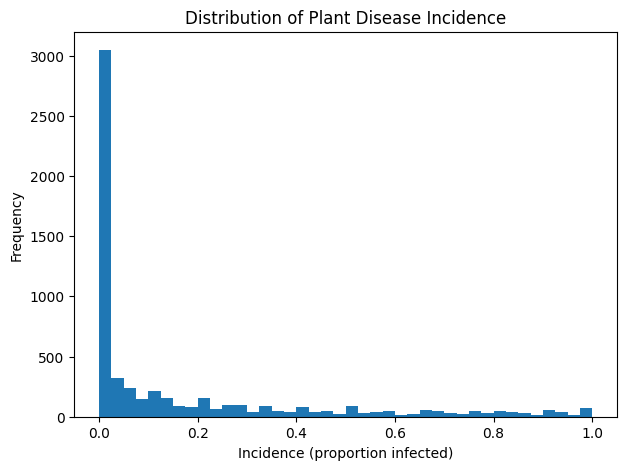

In [14]:
plt.figure(figsize=(7,5))
plt.hist(df_clean["Incidence"], bins=40)
plt.title("Distribution of Plant Disease Incidence")
plt.xlabel("Incidence (proportion infected)")
plt.ylabel("Frequency")
plt.show()

The original Incidence variable is strongly right-skewed. Most values are close to zero, while only a smaller number of observations have high disease incidence. Because of this, I used a log1p transformation before modeling to reduce the skew while still keeping zero values in the data.

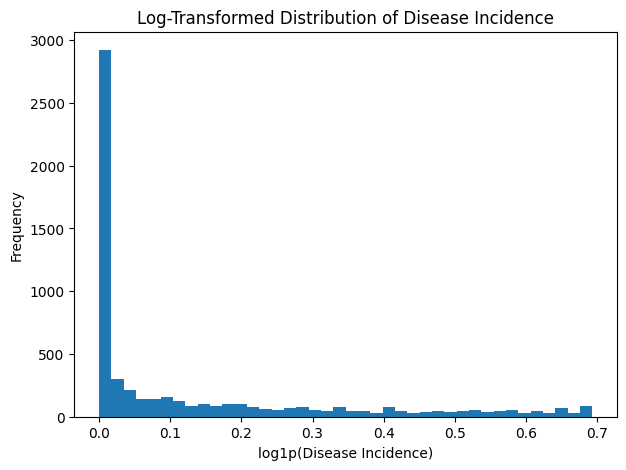

In [15]:
plt.figure(figsize=(7,5))
plt.hist(np.log1p(df["Incidence"]), bins=40)
plt.title("Log-Transformed Distribution of Disease Incidence")
plt.xlabel("log1p(Disease Incidence)")
plt.ylabel("Frequency")
plt.show()

scatterplot: The scatterplot shows variability in disease incidence across the tepurature range. no linear relationship is seen in this plot which suggests that temperature in isolation does not explain the variation in infection levels.

Cleaning justification: the datasets were first both merged(plant disease and climate) using observation identifiers seen on the dataset, this was done so these variables can be analyzed with the incidence rate. The dataset was missing some values and had duplicates so those were removed, some rows missed variables used in alaysis such as disease incidence and main climate varaibles (these were also removed for comparison). The cleaned dataset was stored as df_clean and this is what is used for visualization. 

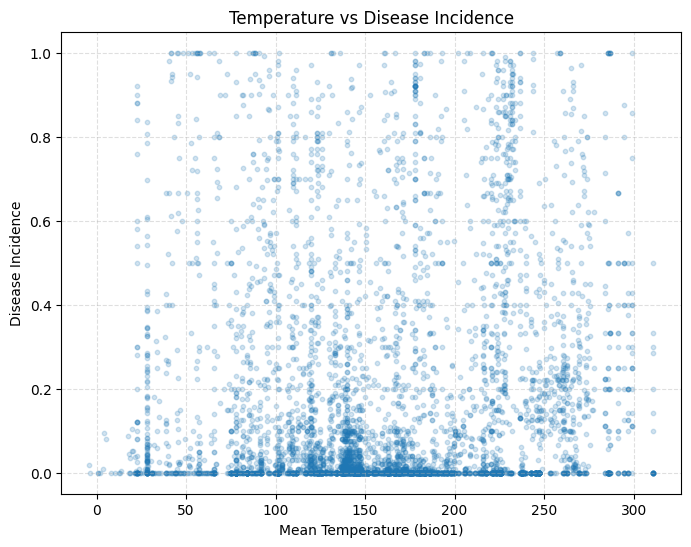

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_clean["bio01"],
    df_clean["Incidence"],
    alpha=0.2,
    s=10
)

plt.title("Temperature vs Disease Incidence")
plt.xlabel("Mean Temperature (bio01)")
plt.ylabel("Disease Incidence")

plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

Precipitation plot: This plot shows that there is variability in disease incidence. High and low infection levels are shown in both high and low precipitation levels, there is no clear linear trend between these two variables, precipitation alone may not strongly determine infection levels in the dataset. 

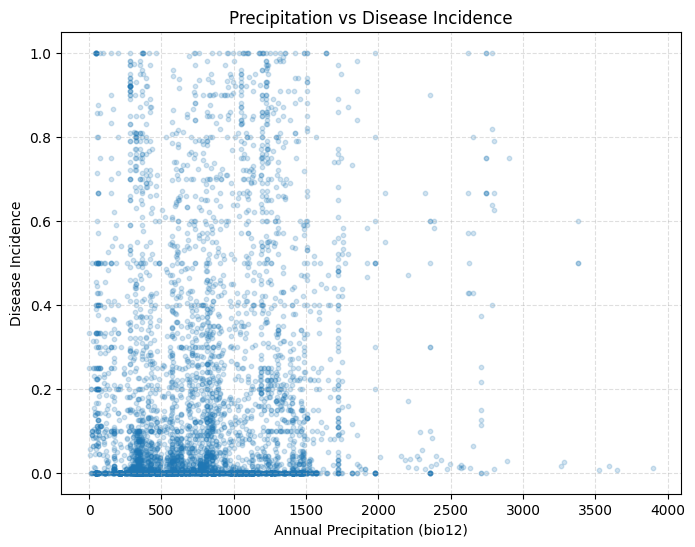

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_clean["bio12"],
    df_clean["Incidence"],
    alpha=0.2,
    s=10
)

plt.title("Precipitation vs Disease Incidence")
plt.xlabel("Annual Precipitation (bio12)")
plt.ylabel("Disease Incidence")

plt.grid(True, linestyle="--", alpha=0.4)

plt.show()